### Import Libraries

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import yaml
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, min, max, dayofweek, month, year, avg, sum, count
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

### Load YAML

In [2]:
with open("config.yaml", "r") as file:
    config = yaml.safe_load(file)

### Set-up PySpark

In [3]:
os.environ["SPARK_LOCAL_IP"] = config["spark"]["spark_local_ip"]

In [4]:
spark = SparkSession.builder \
        .appName(config["spark"]["app_name"]) \
        .master(config["spark"]["master"]) \
        .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/22 15:04:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Load Data

In [5]:
features = spark.read.csv(config["datapaths"]["features"],
                          header=True,
                          inferSchema=True)
features.printSchema()
print(features.show(5))

root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- MarkDown1: string (nullable = true)
 |-- MarkDown2: string (nullable = true)
 |-- MarkDown3: string (nullable = true)
 |-- MarkDown4: string (nullable = true)
 |-- MarkDown5: string (nullable = true)
 |-- CPI: string (nullable = true)
 |-- Unemployment: string (nullable = true)
 |-- IsHoliday: boolean (nullable = true)

+-----+----------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+
|Store|      Date|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|        CPI|Unemployment|IsHoliday|
+-----+----------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+---------+
|    1|2010-02-05|      42.31|     2.572|       NA|       NA|       NA|       NA|       NA|211.0963582|       8.106|    false|
|  

In [6]:
stores = spark.read.csv(config["datapaths"]["stores"],
                       header=True,
                       inferSchema=True)
stores.printSchema()
print(stores.show(5))

root
 |-- Store: integer (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)

+-----+----+------+
|Store|Type|  Size|
+-----+----+------+
|    1|   A|151315|
|    2|   A|202307|
|    3|   B| 37392|
|    4|   A|205863|
|    5|   B| 34875|
+-----+----+------+
only showing top 5 rows
None


In [7]:
train = spark.read.csv(config["datapaths"]["train"],
                       header=True,
                       inferSchema=True)
train.printSchema()
print(train.show(5))

root
 |-- Store: integer (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- IsHoliday: boolean (nullable = true)

+-----+----+----------+------------+---------+
|Store|Dept|      Date|Weekly_Sales|IsHoliday|
+-----+----+----------+------------+---------+
|    1|   1|2010-02-05|     24924.5|    false|
|    1|   1|2010-02-12|    46039.49|     true|
|    1|   1|2010-02-19|    41595.55|    false|
|    1|   1|2010-02-26|    19403.54|    false|
|    1|   1|2010-03-05|     21827.9|    false|
+-----+----+----------+------------+---------+
only showing top 5 rows
None


In [8]:
test = spark.read.csv(config["datapaths"]["test"],
                      header=True,
                      inferSchema=True)
test.printSchema()
print(test.show(5))

root
 |-- Store: integer (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- IsHoliday: boolean (nullable = true)

+-----+----+----------+---------+
|Store|Dept|      Date|IsHoliday|
+-----+----+----------+---------+
|    1|   1|2012-11-02|    false|
|    1|   1|2012-11-09|    false|
|    1|   1|2012-11-16|    false|
|    1|   1|2012-11-23|     true|
|    1|   1|2012-11-30|    false|
+-----+----+----------+---------+
only showing top 5 rows
None


### Data Prepare for Analysis

##### Prepare 'features'

In [9]:
print(f"Shape: ({features.count()},{len(features.columns)})")
features.describe().show()

Shape: (8190,12)


26/08/22 15:04:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+---------------+-----------------+-------------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+-----------------+
|summary|          Store|      Temperature|         Fuel_Price|        MarkDown1|        MarkDown2|         MarkDown3|        MarkDown4|         MarkDown5|               CPI|     Unemployment|
+-------+---------------+-----------------+-------------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+-----------------+
|  count|           8190|             8190|               8190|             8190|             8190|              8190|             8190|              8190|              8190|             8190|
|   mean|           23.0|59.35619780219781| 3.4059918192918217|7032.371785714266|3384.176593632328|1760.1001799058915|3292.935886258671| 4132.216422222234|172.46080918276078|7.826821038790305|
| stddev|12.987966099514| 18.678606

In [ ]:
'''Replacing string "NA" with actual NULL'''
for c in features.columns:
    if dict(features.dtypes)[c] == "string":
        features = features.withColumn(c, when(col(c) == "NA", None).otherwise(col(c)))

features.printSchema()
print(f"Shape: ({features.count()},{len(features.columns)})")
features.describe().show()

root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- MarkDown1: string (nullable = true)
 |-- MarkDown2: string (nullable = true)
 |-- MarkDown3: string (nullable = true)
 |-- MarkDown4: string (nullable = true)
 |-- MarkDown5: string (nullable = true)
 |-- CPI: string (nullable = true)
 |-- Unemployment: string (nullable = true)
 |-- IsHoliday: boolean (nullable = true)

Shape: (8190,12)
+-------+---------------+-----------------+-------------------+-----------------+-----------------+------------------+-----------------+------------------+------------------+-----------------+
|summary|          Store|      Temperature|         Fuel_Price|        MarkDown1|        MarkDown2|         MarkDown3|        MarkDown4|         MarkDown5|               CPI|     Unemployment|
+-------+---------------+-----------------+-------------------+-----------------+-----------------+---------

- Columns 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5' contain some Walmart's promotional data, and not related to our analysis.

In [11]:
features = features.drop(col("MarkDown1"), col("MarkDown2"), col("MarkDown3"), col("MarkDown4"), col("MarkDown5"))
print(f"Shape: ({features.count()},{len(features.columns)})")
features.describe().show()

Shape: (8190,7)
+-------+---------------+-----------------+-------------------+------------------+-----------------+
|summary|          Store|      Temperature|         Fuel_Price|               CPI|     Unemployment|
+-------+---------------+-----------------+-------------------+------------------+-----------------+
|  count|           8190|             8190|               8190|              7605|             7605|
|   mean|           23.0|59.35619780219781| 3.4059918192918217|172.46080918276078|7.826821038790305|
| stddev|12.987966099514| 18.6786068489072|0.43133657110071383| 39.73834609860842|1.877258593917429|
|    min|              1|            -7.29|              2.472|           126.064|           10.064|
|    max|             45|           101.95|              4.468|       228.9764563|            9.966|
+-------+---------------+-----------------+-------------------+------------------+-----------------+



- Drop NULL values

In [22]:
features = features.dropna()
print(f"Columns in features: {features.columns}\n")
features.describe().show()

Columns in features: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday']

+-------+------------------+------------------+------------------+------------------+-----------------+
|summary|             Store|       Temperature|        Fuel_Price|               CPI|     Unemployment|
+-------+------------------+------------------+------------------+------------------+-----------------+
|  count|              7605|              7605|              7605|              7605|             7605|
|   mean|              23.0| 58.29732544378687| 3.389624063116367|172.46080918276078|7.826821038790305|
| stddev|12.988027100939922|18.709861638737568|0.4414606387374794| 39.73834609860842|1.877258593917429|
|    min|                 1|             -7.29|             2.472|           126.064|           10.064|
|    max|                45|            100.14|             4.468|       228.9764563|            9.966|
+-------+------------------+------------------+----------------

In [13]:
for c in features.columns:
    print(f"NULL value Count in column {c}: {features.filter(col(c).isNull()).count()}")

NULL value Count in column Store: 0
NULL value Count in column Date: 0
NULL value Count in column Temperature: 0
NULL value Count in column Fuel_Price: 0
NULL value Count in column CPI: 0
NULL value Count in column Unemployment: 0
NULL value Count in column IsHoliday: 0


##### Prepare 'stores'

In [25]:
print(f"Shape: ({stores.count()},{len(stores.columns)})")
print(f"Columns in stores: {stores.columns}\n")
stores.describe().show()

Shape: (45,3)
Columns in stores: ['Store', 'Type', 'Size']

+-------+------------------+----+-----------------+
|summary|             Store|Type|             Size|
+-------+------------------+----+-----------------+
|  count|                45|  45|               45|
|   mean|              23.0|NULL|         130287.6|
| stddev|13.133925536563698|NULL|63825.27199115923|
|    min|                 1|   A|            34875|
|    max|                45|   C|           219622|
+-------+------------------+----+-----------------+



In [26]:
for c in stores.columns:
    print(f"NULL value Count in column {c}: {stores.filter(col(c).isNull()).count()}")

NULL value Count in column Store: 0
NULL value Count in column Type: 0
NULL value Count in column Size: 0


##### Prepare 'train'

In [27]:
print(f"Shape: ({train.count()},{len(train.columns)})")
print(f"Columns in train: {train.columns}\n")
train.describe().show()

Shape: (421570,5)
Columns in train: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

+-------+------------------+------------------+------------------+
|summary|             Store|              Dept|      Weekly_Sales|
+-------+------------------+------------------+------------------+
|  count|            421570|            421570|            421570|
|   mean|22.200545579619043| 44.26031738501317|15981.258123467413|
| stddev|12.785297389902782|30.492054015786017| 22711.18351916329|
|    min|                 1|                 1|          -4988.94|
|    max|                45|                99|         693099.36|
+-------+------------------+------------------+------------------+



In [28]:
for c in train.columns:
    print(f"NULL value Count in column {c}: {train.filter(col(c).isNull()).count()}")

NULL value Count in column Store: 0
NULL value Count in column Dept: 0
NULL value Count in column Date: 0
NULL value Count in column Weekly_Sales: 0
NULL value Count in column IsHoliday: 0


##### Prepare 'test'

In [29]:
print(f"Shape: ({test.count()},{len(test.columns)})")
print(f"Columns in test: {test.columns}\n")
test.describe().show()

Shape: (115064,4)
Columns in test: ['Store', 'Dept', 'Date', 'IsHoliday']

+-------+------------------+------------------+
|summary|             Store|              Dept|
+-------+------------------+------------------+
|  count|            115064|            115064|
|   mean|  22.2382065633039| 44.33952409094069|
| stddev|12.809929591378935|30.656410130030174|
|    min|                 1|                 1|
|    max|                45|                99|
+-------+------------------+------------------+



In [30]:
for c in test.columns:
    print(f"NULL value count in column {c}: {test.filter(col(c).isNull()).count()}")

NULL value count in column Store: 0
NULL value count in column Dept: 0
NULL value count in column Date: 0
NULL value count in column IsHoliday: 0


### Merge All the data to analyze

- Let's merge features, stores and train for more insights: "Store is commin in all the datasets.
- Start date and End date in 'train' are 2010-02-05 and 2010-10-26 respectively, while Start Date in 'feature' is 2010-02-05 and End Date in 'feature' is 2013-07-26. Hence, in merging 'train' and 'feature' on ['Store', 'Date', 'IsHoliday'] Sales data after '2012-10-26' would not be considered in merging.

In [77]:
merged_df = features.join(stores, on = "Store", how = "inner")
print(f"Merged data shape: ({merged_df.count(), len(merged_df.columns)})")
print(merged_df.show(5))
merged_df = merged_df.join(train, on = ["Date", "Store", "isHoliday"], how = "inner")
print(f"Merged data shape: ({merged_df.count(), len(merged_df.columns)})")
merged_df = merged_df.orderBy(col("Date").asc())
merged_df.show(5)

Merged data shape: ((7605, 9))
+-----+----------+-----------+----------+-----------+------------+---------+----+------+
|Store|      Date|Temperature|Fuel_Price|        CPI|Unemployment|IsHoliday|Type|  Size|
+-----+----------+-----------+----------+-----------+------------+---------+----+------+
|    1|2010-02-05|      42.31|     2.572|211.0963582|       8.106|    false|   A|151315|
|    1|2010-02-12|      38.51|     2.548|211.2421698|       8.106|     true|   A|151315|
|    1|2010-02-19|      39.93|     2.514|211.2891429|       8.106|    false|   A|151315|
|    1|2010-02-26|      46.63|     2.561|211.3196429|       8.106|    false|   A|151315|
|    1|2010-03-05|       46.5|     2.625|211.3501429|       8.106|    false|   A|151315|
+-----+----------+-----------+----------+-----------+------------+---------+----+------+
only showing top 5 rows
None
Merged data shape: ((421570, 11))
+----------+-----+---------+-----------+----------+-----------+------------+----+------+----+------------

In [ ]:
'''Adding Date-based features'''
merged_df = merged_df.withColumn("DayofWeek", dayofweek("Date")) \
                     .withColumn("Month", month("Date")) \
                     .withColumn("Year", year("Date"))

In [85]:
print(merged_df.show(5))
print(f"Merged data shape: ({merged_df.count(), len(merged_df.columns)})")
merged_df.describe().show()

+----------+-----+---------+-----------+----------+-----------+------------+----+------+----+------------+---------+----------+-----+----+
|      Date|Store|IsHoliday|Temperature|Fuel_Price|        CPI|Unemployment|Type|  Size|Dept|Weekly_Sales|DayofWeek|Weekofyear|Month|Year|
+----------+-----+---------+-----------+----------+-----------+------------+----+------+----+------------+---------+----------+-----+----+
|2010-02-05|   45|    false|      27.31|     2.784|181.8711898|       8.992|   B|118221|  10|    15473.72|        6|         5|    2|2010|
|2010-02-05|   40|    false|      14.48|     2.788|131.5279032|       5.892|   A|155083|   1|    18116.85|        6|         5|    2|2010|
|2010-02-05|   24|    false|      22.43|     2.954|131.5279032|       8.326|   A|203819|   1|    17309.89|        6|         5|    2|2010|
|2010-02-05|   40|    false|      14.48|     2.788|131.5279032|       5.892|   A|155083|   6|     3634.06|        6|         5|    2|2010|
|2010-02-05|    1|    false

### Let's analyze the data

##### Using Correlation heatmap

In [79]:
merged_df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Store: integer (nullable = true)
 |-- IsHoliday: boolean (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- CPI: string (nullable = true)
 |-- Unemployment: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Weekly_Sales: double (nullable = true)



In [80]:
merged_df = merged_df.withColumn("CPI", col("CPI").cast("double"))
merged_df = merged_df.withColumn("Unemployment", col("Unemployment").cast("double"))
merged_df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Store: integer (nullable = true)
 |-- IsHoliday: boolean (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- CPI: double (nullable = true)
 |-- Unemployment: double (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Weekly_Sales: double (nullable = true)



In [93]:
merged_df.groupBy("Date").count().show(20)

+----------+-----+
|      Date|count|
+----------+-----+
|2010-09-24| 2932|
|2011-05-06| 2974|
|2011-10-07| 2958|
|2011-11-18| 2961|
|2012-09-21| 2959|
|2012-03-30| 2961|
|2010-06-11| 2909|
|2011-08-05| 2929|
|2011-04-29| 2952|
|2010-04-16| 2944|
|2010-03-19| 2943|
|2011-09-02| 2949|
|2012-08-31| 2962|
|2011-03-18| 2949|
|2012-05-25| 2941|
|2012-01-06| 2973|
|2010-07-23| 2923|
|2012-03-02| 2990|
|2010-10-22| 2934|
|2012-01-20| 2959|
+----------+-----+
only showing top 20 rows


26/08/22 16:30:02 WARN PearsonCorrelation: Pearson correlation matrix contains NaN values.


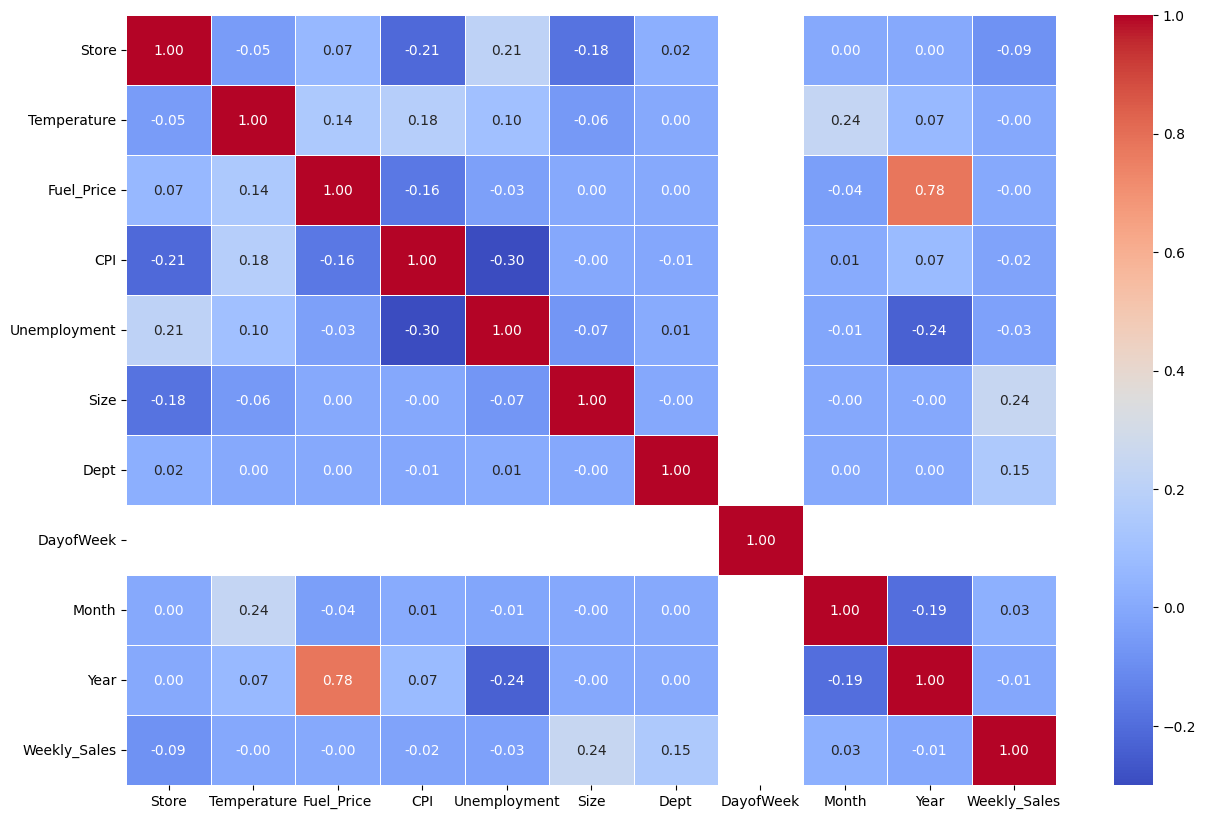

In [90]:
numerical_features = ["Store", "Temperature", "Fuel_Price", "CPI", "Unemployment" ,"Size", "Dept", "DayofWeek", "Month", "Year", "Weekly_Sales"]
assembler = VectorAssembler(inputCols=numerical_features, outputCol="features")
vector_df = assembler.transform(merged_df)
corr_matrix = Correlation.corr(vector_df, "features", method="pearson").head()[0]
corr_df = pd.DataFrame(corr_matrix.toArray(), columns=numerical_features, index=numerical_features)

plt.figure(figsize=(15, 10))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", linewidths="0.5", fmt=".2f")
plt.show()

- From correlation heatmap, it looks like 'Temperature' and 'Fuel_Price' have no effect on 'Weekly_Sales'.
- There is only one day of week (Friday) in the data.
- 'Year' also has almost no effect.

##### Using Scatter-plot

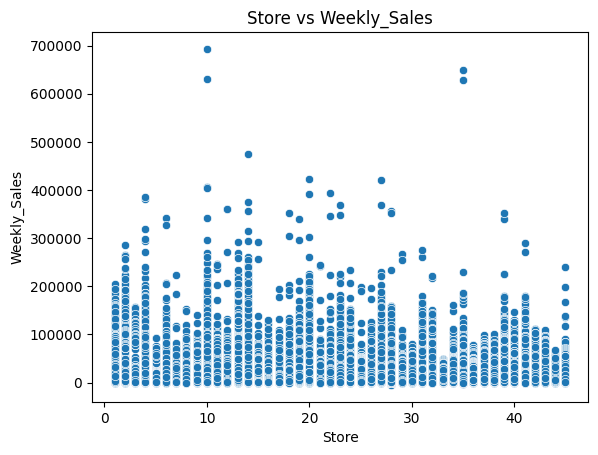

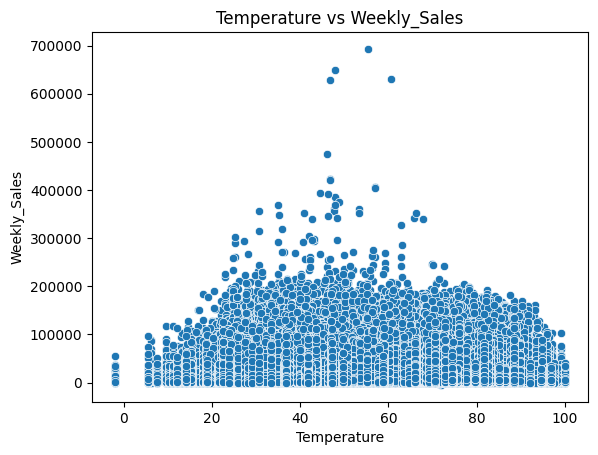

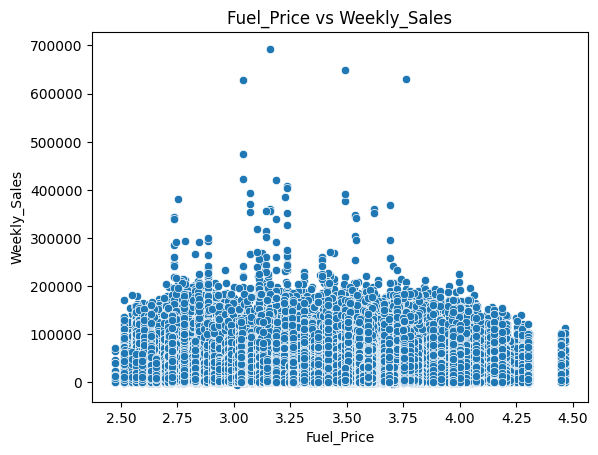

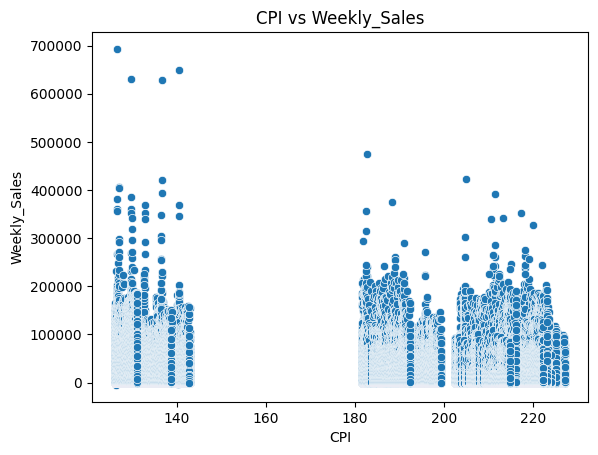

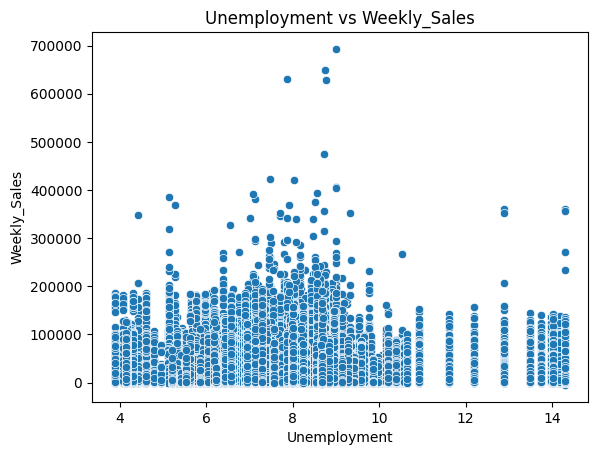

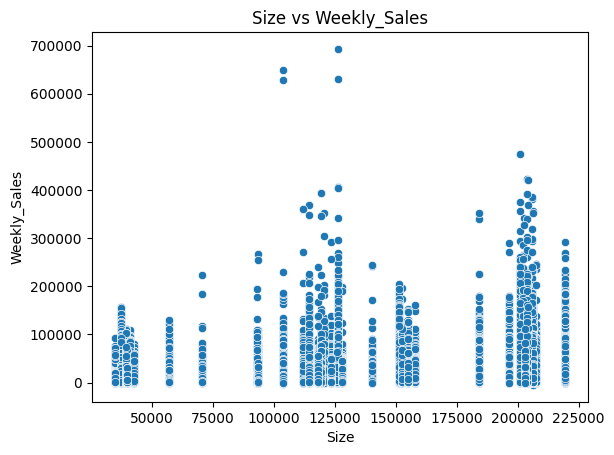

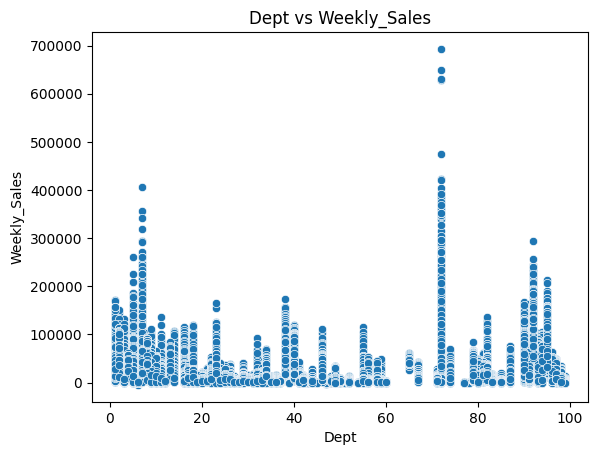

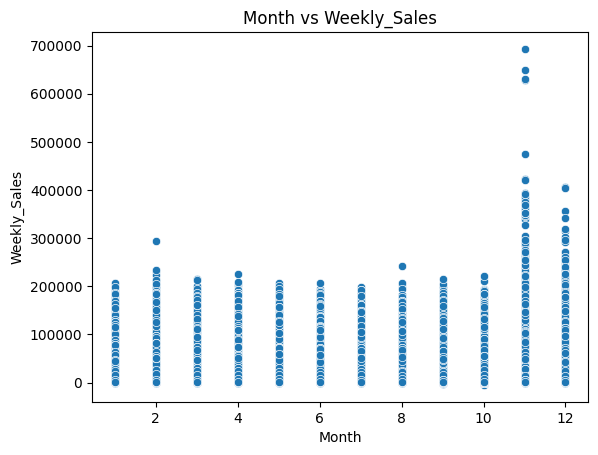

In [102]:
scatterplot_features = ["Store", "Temperature", "Fuel_Price", "CPI", "Unemployment" ,"Size", "Dept", "Month"]
for c in scatterplot_features:
    c_data = merged_df.select(c, "Weekly_Sales").toPandas()
    sns.scatterplot(data = c_data, x=c, y="Weekly_Sales")
    plt.title(f"{c} vs Weekly_Sales")
    plt.show()

- Sales in Nov and Dec months are comparatively higher, might be because of Thanksgiving and Christmas in USA.
- Fuel_Price affects sales slightly only if it is too high(>4.1).
- If Temparature is too high or too low then it affects sales.

##### Using Bar-plot

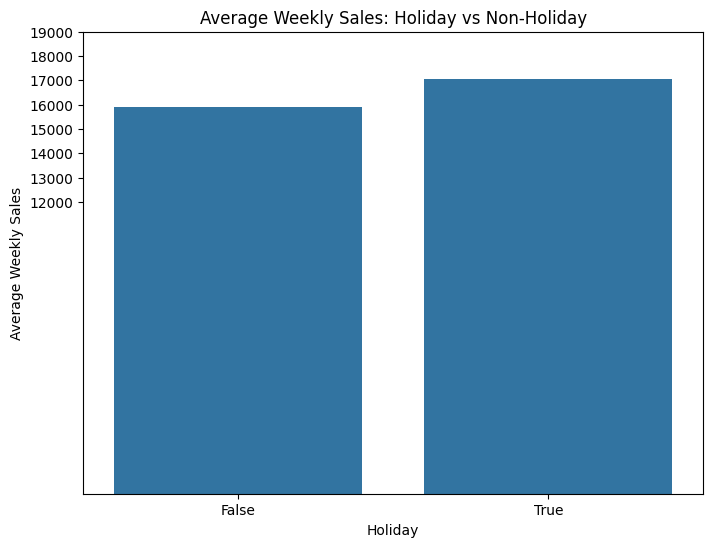

In [132]:
IsHoliday_df = merged_df.groupBy("IsHoliday").agg(count("*").alias("Count"), avg("Weekly_Sales").alias("Avg Weekly Sales"), sum("Weekly_Sales").alias("Total Weekly Sales")).toPandas()

plt.figure(figsize=(8, 6))
sns.barplot(data=IsHoliday_df, x="IsHoliday", y="Avg Weekly Sales")
plt.yticks(range(12000, 20000, 1000))
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Weekly Sales")
plt.show()

- Clearly, people shop more on holidays.

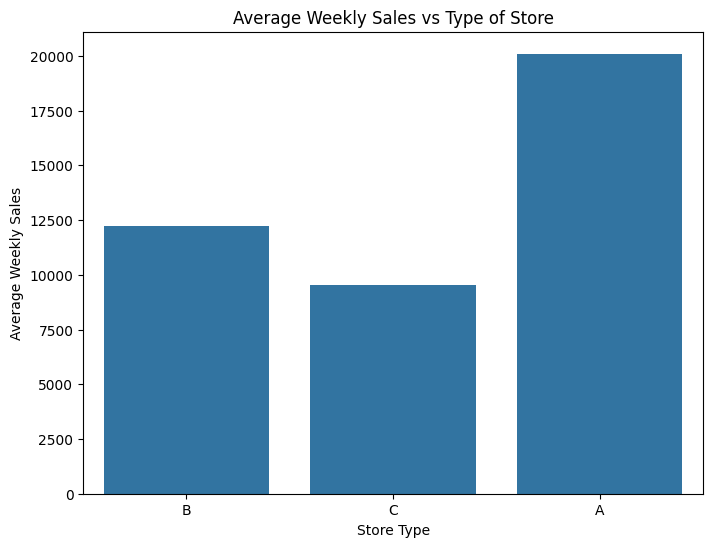

In [131]:
Type_df = merged_df.groupBy("Type").agg(count("*").alias("Count"), avg("Weekly_Sales").alias("Avg Weekly Sales"), sum("Weekly_Sales").alias("Total Weekly Sales")).toPandas()

plt.figure(figsize=(8, 6))
sns.barplot(data=Type_df, x="Type", y="Avg Weekly Sales")
# plt.yticks(range(12000, 20000, 1000))
plt.title("Average Weekly Sales vs Type of Store")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")
plt.show()

- Store type 'A' has the best average weekly sales, might be because of store type 'A' are bigger in size than 'B' and 'C'.